In [13]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import itertools

# Statistik dan time series
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Transformasi dan machine learning
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Abaikan peringatan yang tidak perlu
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [14]:
# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

In [16]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive berhasil di-mount")
except:
    print("Tidak menggunakan Google Colab atau Google Drive sudah di-mount")

# Path file (sesuaikan dengan lokasi Anda)
FILE_PATH = '/content/drive/MyDrive//idAI/dataset/store5.csv'
OUTPUT_PATH = '/content/drive/MyDrive//idAI/dataset/store5.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount


LOAD DATA

In [17]:
df_store = pd.read_csv(FILE_PATH)
print(f"Data berhasil dimuat dengan {df_store.shape[0]} baris dan {df_store.shape[1]} kolom")

Data berhasil dimuat dengan 55572 baris dan 7 kolom


In [18]:
df_store.to_excel(OUTPUT_PATH, index=False)
print(f"File berhasil disimpan ke: {OUTPUT_PATH}")

File berhasil disimpan ke: /content/drive/MyDrive//idAI/dataset/store5.xlsx


In [19]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


In [20]:
df_store.describe()

,id,store_nbr,sales,onpromotion,dcoilwtico
count,5.557200e+04,55572.0,55572.000000,55572.000000,38379.000000
mean,1.501021e+06,5.0,280.580231,2.687864,67.925589
std,8.662894e+05,0.0,652.588149,11.748996,25.666659
min,1.452000e+03,5.0,0.000000,0.000000,26.190000
25%,7.512365e+05,5.0,1.000000,0.000000,46.380000
50%,1.501021e+06,5.0,19.000000,0.000000,53.330000
75%,2.250806e+06,5.0,237.000000,0.000000,95.800000
max,3.000590e+06,5.0,8216.620000,182.000000,110.620000


In [21]:
missing = df_store.isnull().sum()
print(missing)

id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        0
dcoilwtico     17193
dtype: int64


In [22]:
df_store.head()

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN


In [23]:
family_sales = df_store.groupby('family')['sales'].sum().sort_values(ascending=False)
top3_sales = family_sales.head(3)
print(top3_sales)

family
GROCERY I    5262681.658
BEVERAGES    2533831.000
CLEANING     1667748.000
Name: sales, dtype: float64


PREPROCESSING DATA

In [24]:
# Konversi tanggal ke datetime
df_store.loc[:, 'date'] = pd.to_datetime(df_store['date'])

# Interpolasi nilai yang hilang di kolom dcoilwtico
df_store.loc[:, 'dcoilwtico_interpolate'] = df_store['dcoilwtico'].interpolate(method='polynomial', order=2)

# Gunakan ffill dan bfill untuk nilai yang masih missing
df_store.loc[:, 'dcoilwtico_interpolate'] = df_store['dcoilwtico_interpolate'].ffill().bfill()

# Cek missing values setelah preprocessing
print("\nMissing Values Setelah Preprocessing:")
print(df_store.isnull().sum())


Missing Values Setelah Preprocessing:
id                            0
date                          0
store_nbr                     0
family                        0
sales                         0
onpromotion                   0
dcoilwtico                17193
dcoilwtico_interpolate        0
dtype: int64


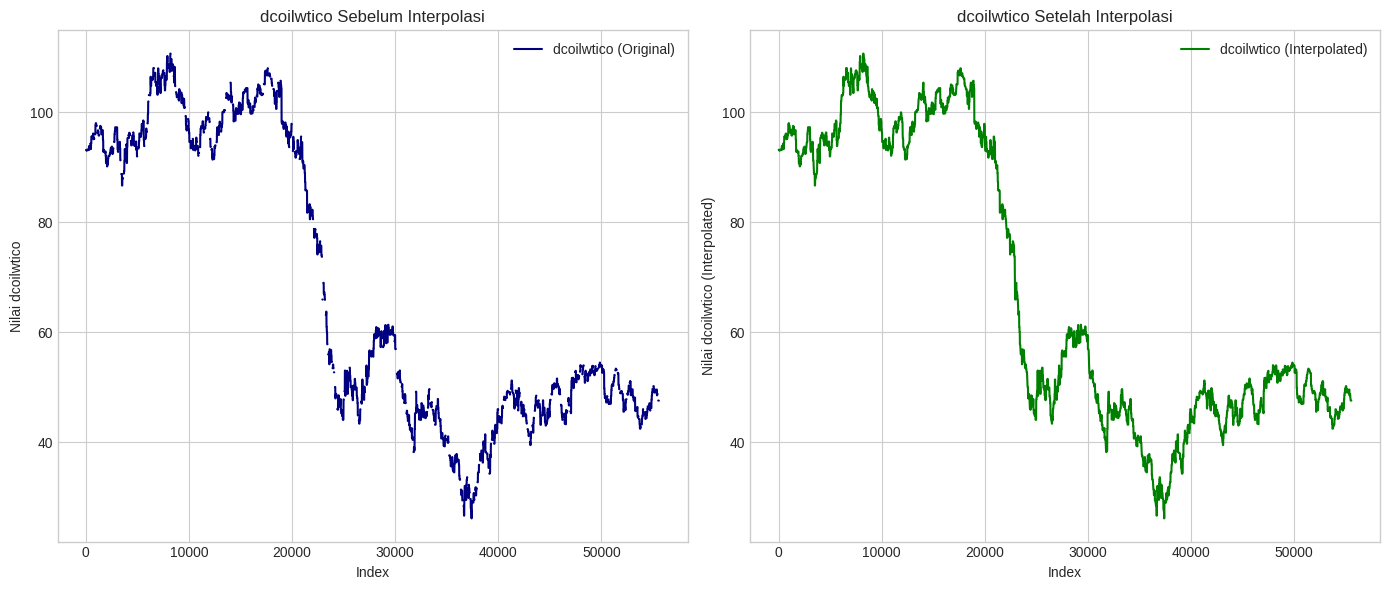

In [25]:
plt.figure(figsize=(14, 6))

# Plot data asli
plt.subplot(1, 2, 1)
plt.plot(df_store['dcoilwtico'], label='dcoilwtico (Original)', color='navy')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Index')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot data setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_store['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='green')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Index')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

Analisis Korelasi

                           sales  onpromotion  dcoilwtico_interpolate
sales                   1.000000     0.448904               -0.041183
onpromotion             0.448904     1.000000               -0.158960
dcoilwtico_interpolate -0.041183    -0.158960                1.000000


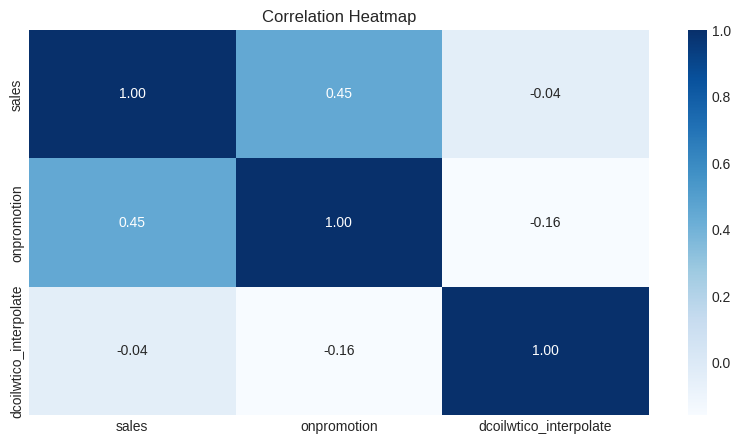

In [26]:
correlation = df_store[['sales', 'onpromotion', 'dcoilwtico_interpolate']].corr()
print(correlation)

plt.figure(figsize=(10, 5))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

FILTER DATA UNTUK KATEGORI CLEANING

In [27]:
df_cleaning = df_store[df_store['family'] == 'CLEANING'].copy()
print(f"Data untuk kategori 'CLEANING' memiliki {df_cleaning.shape[0]} baris")

# Pilih kolom yang diperlukan
df_cleaning = df_cleaning[['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'dcoilwtico']].copy()

# Cek tanggal yang hilang
print("\n======= CEK TANGGAL YANG HILANG =======")
full_date_range = pd.date_range(start=df_cleaning['date'].min(), end=df_cleaning['date'].max(), freq='D')
missing_dates = full_date_range.difference(df_cleaning['date'])

if len(missing_dates) > 0:
    print(f"Ditemukan {len(missing_dates)} tanggal yang hilang:")
    print(missing_dates)

    # Buat dataframe untuk tanggal yang hilang
    missing_df = pd.DataFrame({'date': missing_dates})

    # Tambahkan kolom lain dengan nilai default yang sesuai
    missing_df['store_nbr'] = df_cleaning['store_nbr'].iloc[0]
    missing_df['family'] = 'CLEANING'
    missing_df['sales'] = 0  # Asumsi tidak ada penjualan pada hari libur
    missing_df['onpromotion'] = 0  # Asumsi tidak ada promosi pada hari libur
    missing_df['dcoilwtico'] = np.nan  # Akan diinterpolasi nanti

    # Gabungkan dengan DataFrame asli
    df_cleaning = pd.concat([df_cleaning, missing_df]).sort_values('date')

    # Interpolasi ulang dcoilwtico
    df_cleaning.loc[:, 'dcoilwtico_interpolate'] = (
        df_cleaning['dcoilwtico']
        .interpolate(method='polynomial', order=2)
        .ffill()
        .bfill()
    )
else:
    print("Tidak ada tanggal yang hilang.")

Data untuk kategori 'CLEANING' memiliki 1684 baris

======= CEK TANGGAL YANG HILANG =======
Ditemukan 4 tanggal yang hilang:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


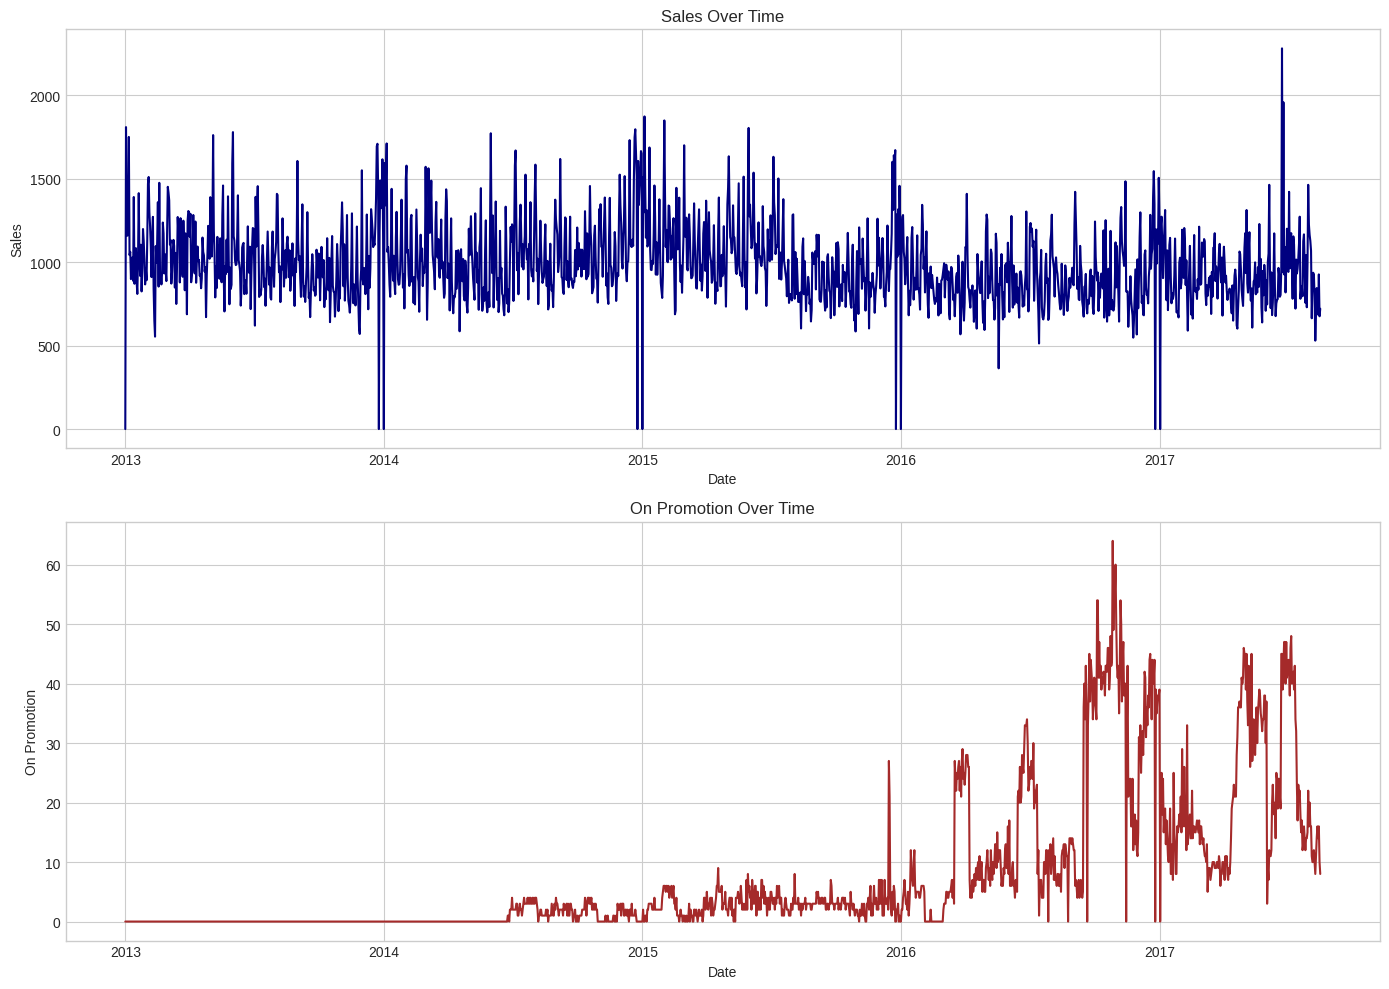

In [28]:
plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_cleaning['date'], df_cleaning['sales'], color='navy')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_cleaning['date'], df_cleaning['onpromotion'], color='brown')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

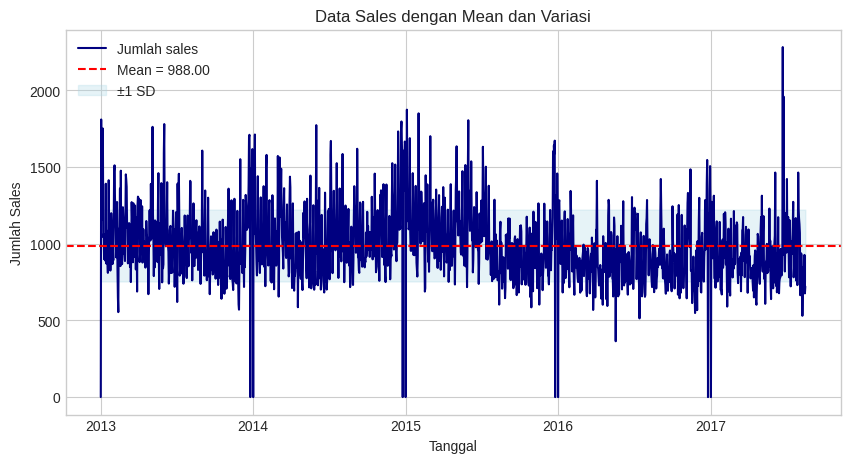

In [29]:
# Set date sebagai index untuk plotting
df_cleaning_indexed = df_cleaning.set_index('date')

# Statistik Sales
mean_sales = df_cleaning_indexed['sales'].mean()
std_sales = df_cleaning_indexed['sales'].std()

plt.figure(figsize=(10, 5))
plt.plot(df_cleaning_indexed['sales'], label='Jumlah sales', color='navy')

plt.axhline(y=mean_sales, color='red', linestyle='--', label=f'Mean = {mean_sales:.2f}')

plt.fill_between(
    df_cleaning_indexed.index,
    mean_sales - std_sales,
    mean_sales + std_sales,
    color='lightblue',
    alpha=0.3,
    label='±1 SD'
)

plt.title('Data Sales dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Sales')
plt.grid(True)
plt.legend()
plt.show()

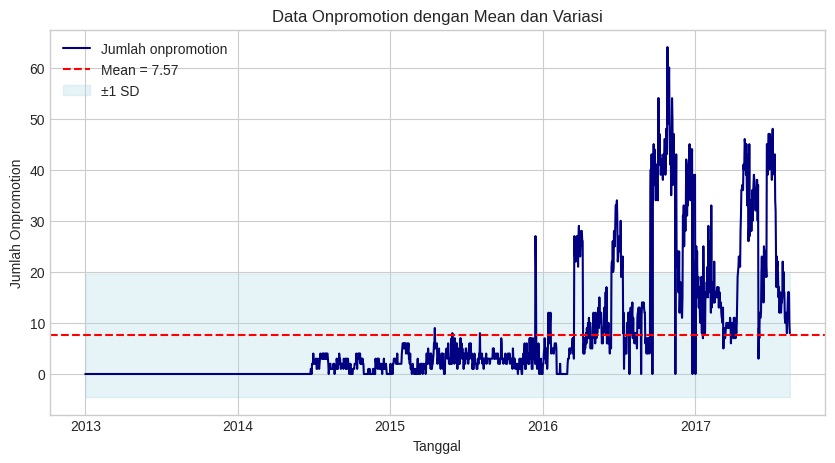

In [30]:
# Statistik Onpromotion
mean_onpromo = df_cleaning_indexed['onpromotion'].mean()
std_onpromo = df_cleaning_indexed['onpromotion'].std()

plt.figure(figsize=(10, 5))
plt.plot(df_cleaning_indexed['onpromotion'], label='Jumlah onpromotion', color='navy')

plt.axhline(y=mean_onpromo, color='red', linestyle='--', label=f'Mean = {mean_onpromo:.2f}')

plt.fill_between(
    df_cleaning_indexed.index,
    mean_onpromo - std_onpromo,
    mean_onpromo + std_onpromo,
    color='lightblue',
    alpha=0.3,
    label='±1 SD'
)

plt.title('Data Onpromotion dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Onpromotion')
plt.grid(True)
plt.legend()
plt.show()

UJI STASIONERITAS ADF TEST

In [31]:
def adf_test(series, series_name="Time Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test untuk {series_name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> Data stasioner (reject H0)")
        return True
    else:
        print("=> Data tidak stasioner (fail to reject H0)")
        return False

# Uji stasioneritas Sales
is_sales_stationary = adf_test(df_cleaning_indexed['sales'], "Sales")

# Uji stasioneritas Onpromotion
is_onpromo_stationary = adf_test(df_cleaning_indexed['onpromotion'], "Onpromotion")

# Jika onpromotion tidak stasioner, lakukan differencing
if not is_onpromo_stationary:
    df_cleaning_indexed.loc[:, 'onpromotion_diff'] = df_cleaning_indexed['onpromotion'].diff()

    # Uji ulang stasioneritas
    print("\nStasioneritas Onpromotion setelah differencing:")
    is_onpromo_diff_stationary = adf_test(
        df_cleaning_indexed['onpromotion_diff'].dropna(),
        "Onpromotion (differenced)"
    )

ADF Test untuk Sales:
ADF Statistic: -5.3878
p-value: 0.0000
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data stasioner (reject H0)
ADF Test untuk Onpromotion:
ADF Statistic: -2.8026
p-value: 0.0579
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data tidak stasioner (fail to reject H0)

Stasioneritas Onpromotion setelah differencing:
ADF Test untuk Onpromotion (differenced):
ADF Statistic: -11.2218
p-value: 0.0000
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data stasioner (reject H0)


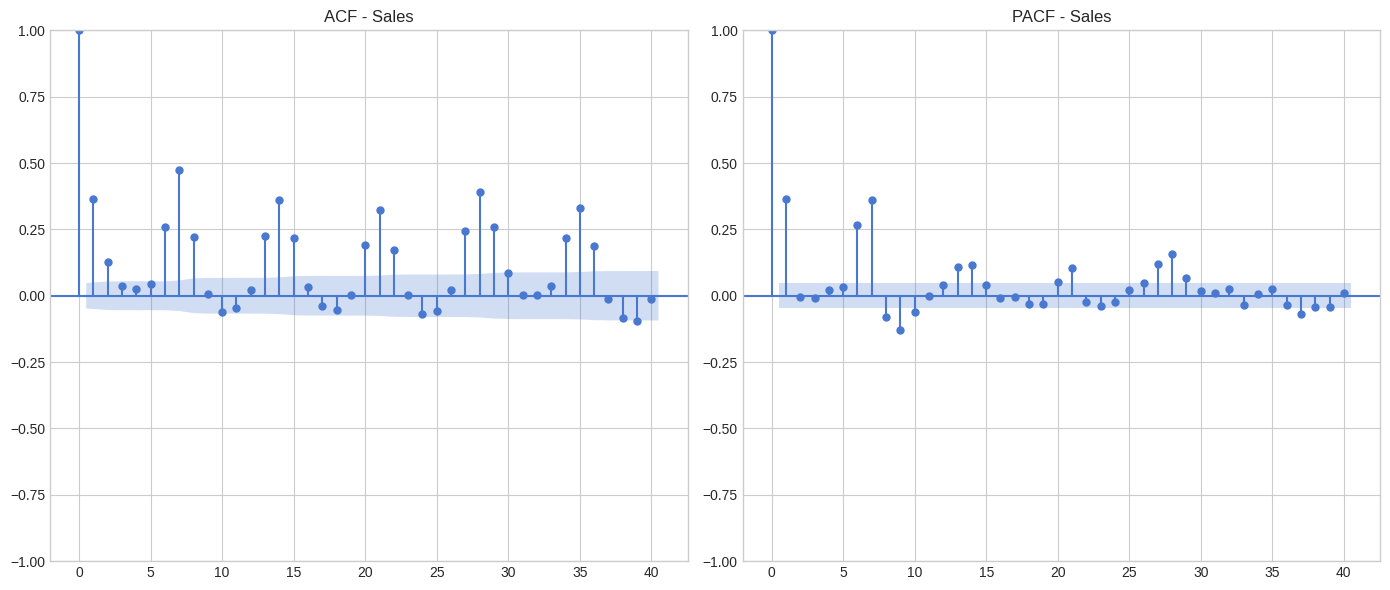

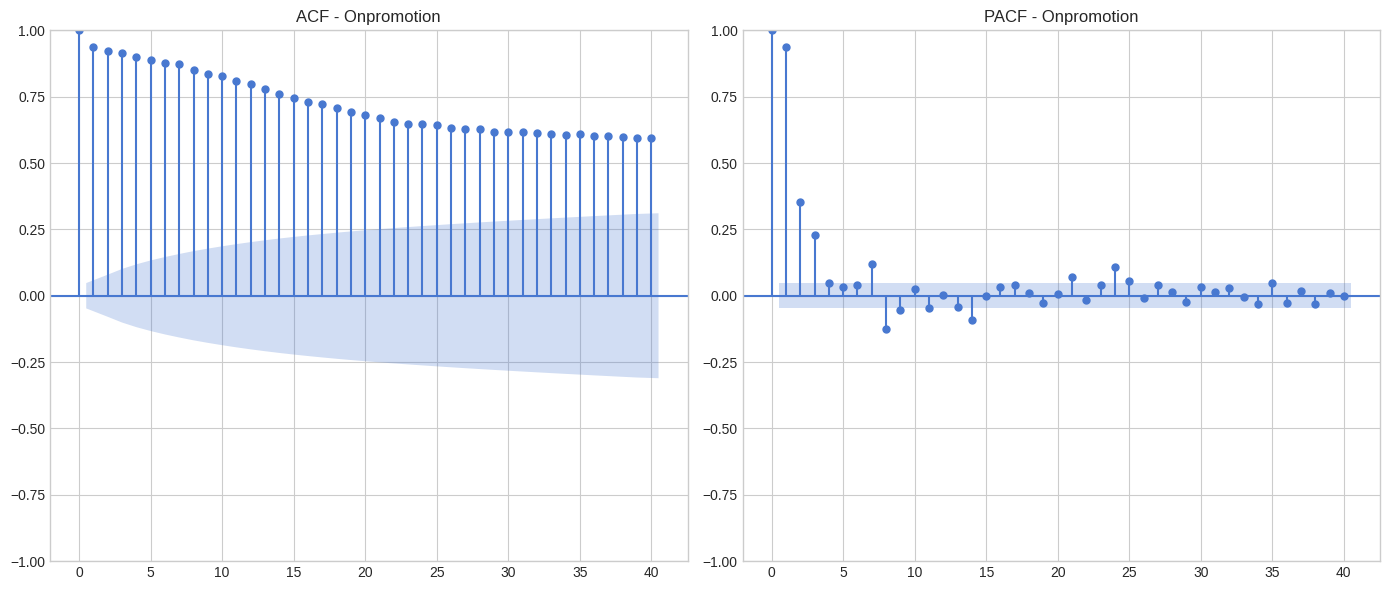

In [32]:

# ACF dan PACF untuk Sales
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plot_acf(df_cleaning_indexed['sales'].dropna(), lags=40, ax=plt.gca())
plt.title("ACF - Sales")
plt.grid(True)

plt.subplot(1, 2, 2)
plot_pacf(df_cleaning_indexed['sales'].dropna(), lags=40, ax=plt.gca())
plt.title("PACF - Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

# ACF dan PACF untuk Onpromotion
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plot_acf(df_cleaning_indexed['onpromotion'].dropna(), lags=40, ax=plt.gca())
plt.title("ACF - Onpromotion")
plt.grid(True)

plt.subplot(1, 2, 2)
plot_pacf(df_cleaning_indexed['onpromotion'].dropna(), lags=40, ax=plt.gca())
plt.title("PACF - Onpromotion")
plt.grid(True)

plt.tight_layout()
plt.show()


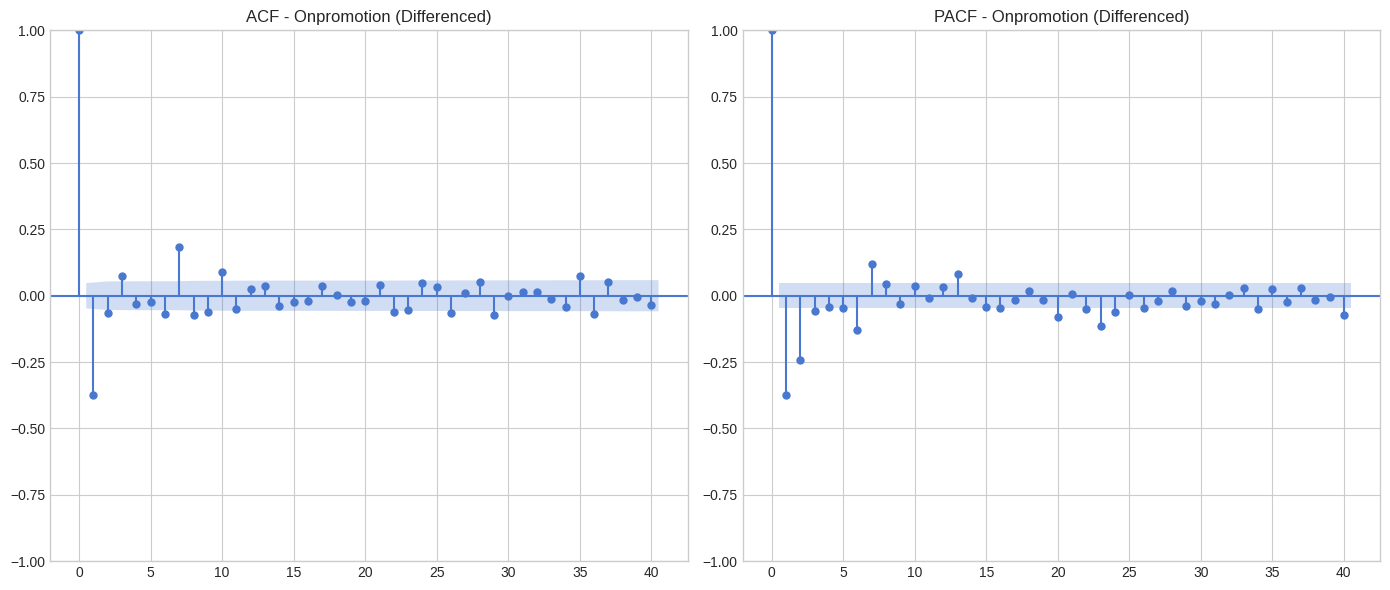

In [33]:
if not is_onpromo_stationary:
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plot_acf(df_cleaning_indexed['onpromotion_diff'].dropna(), lags=40, ax=plt.gca())
    plt.title("ACF - Onpromotion (Differenced)")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plot_pacf(df_cleaning_indexed['onpromotion_diff'].dropna(), lags=40, ax=plt.gca())
    plt.title("PACF - Onpromotion (Differenced)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

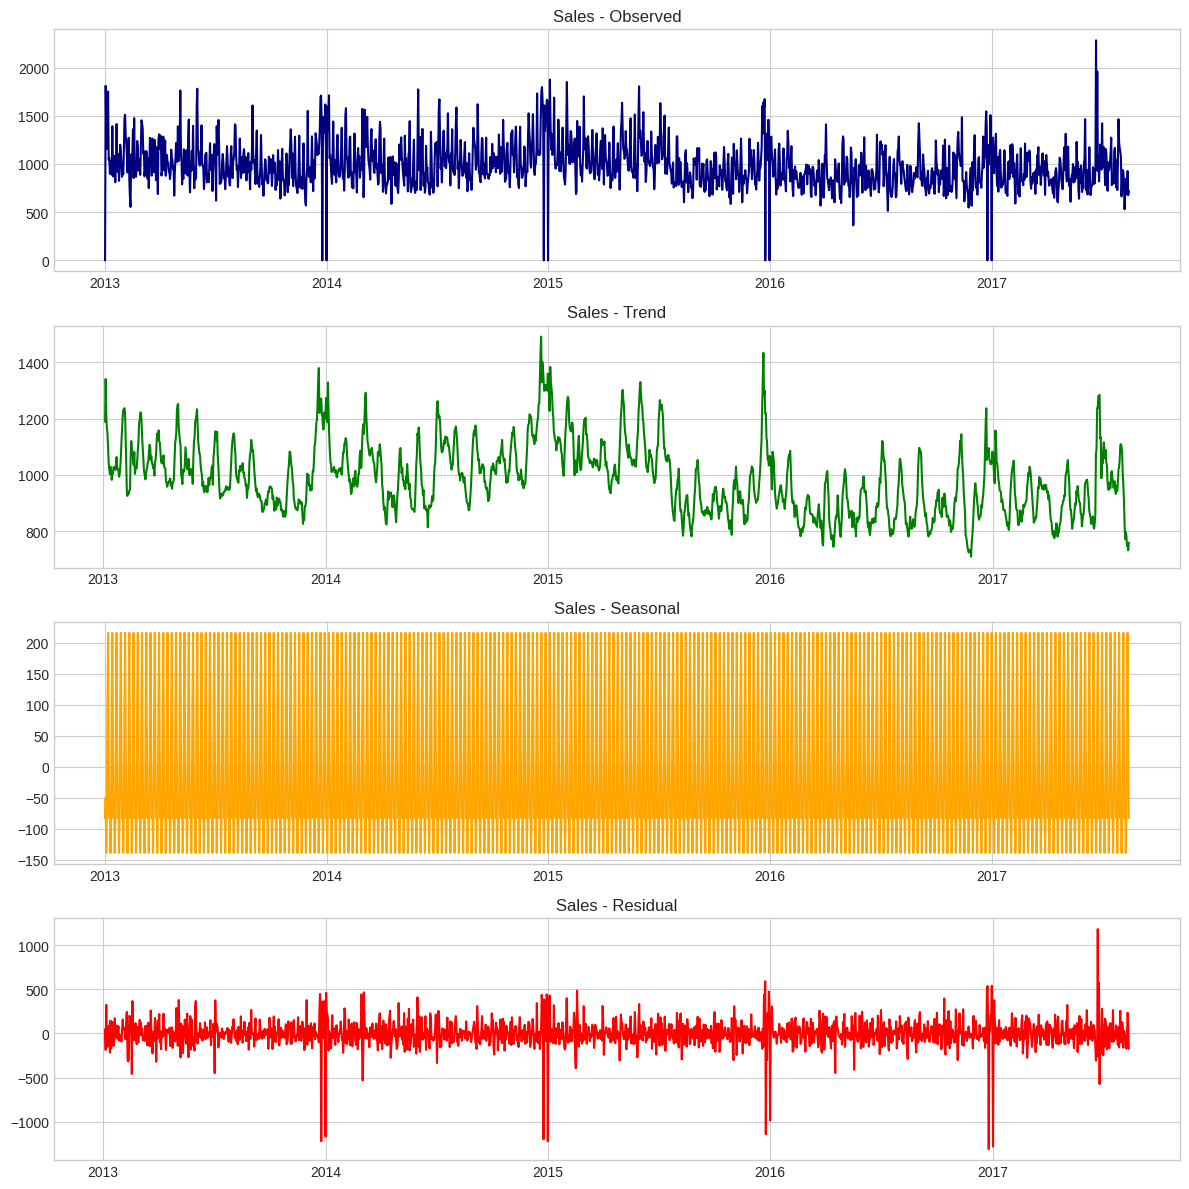

In [35]:
# Decomposition untuk Sales
decomp_sales = seasonal_decompose(df_cleaning_indexed['sales'], model='additive', period=7)

plt.figure(figsize=(12, 12))
plt.subplot(4, 1, 1)
plt.plot(decomp_sales.observed, color='navy')
plt.title("Sales - Observed")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(decomp_sales.trend, color='green')
plt.title("Sales - Trend")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(decomp_sales.seasonal, color='orange')
plt.title("Sales - Seasonal")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(decomp_sales.resid, color='red')
plt.title("Sales - Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

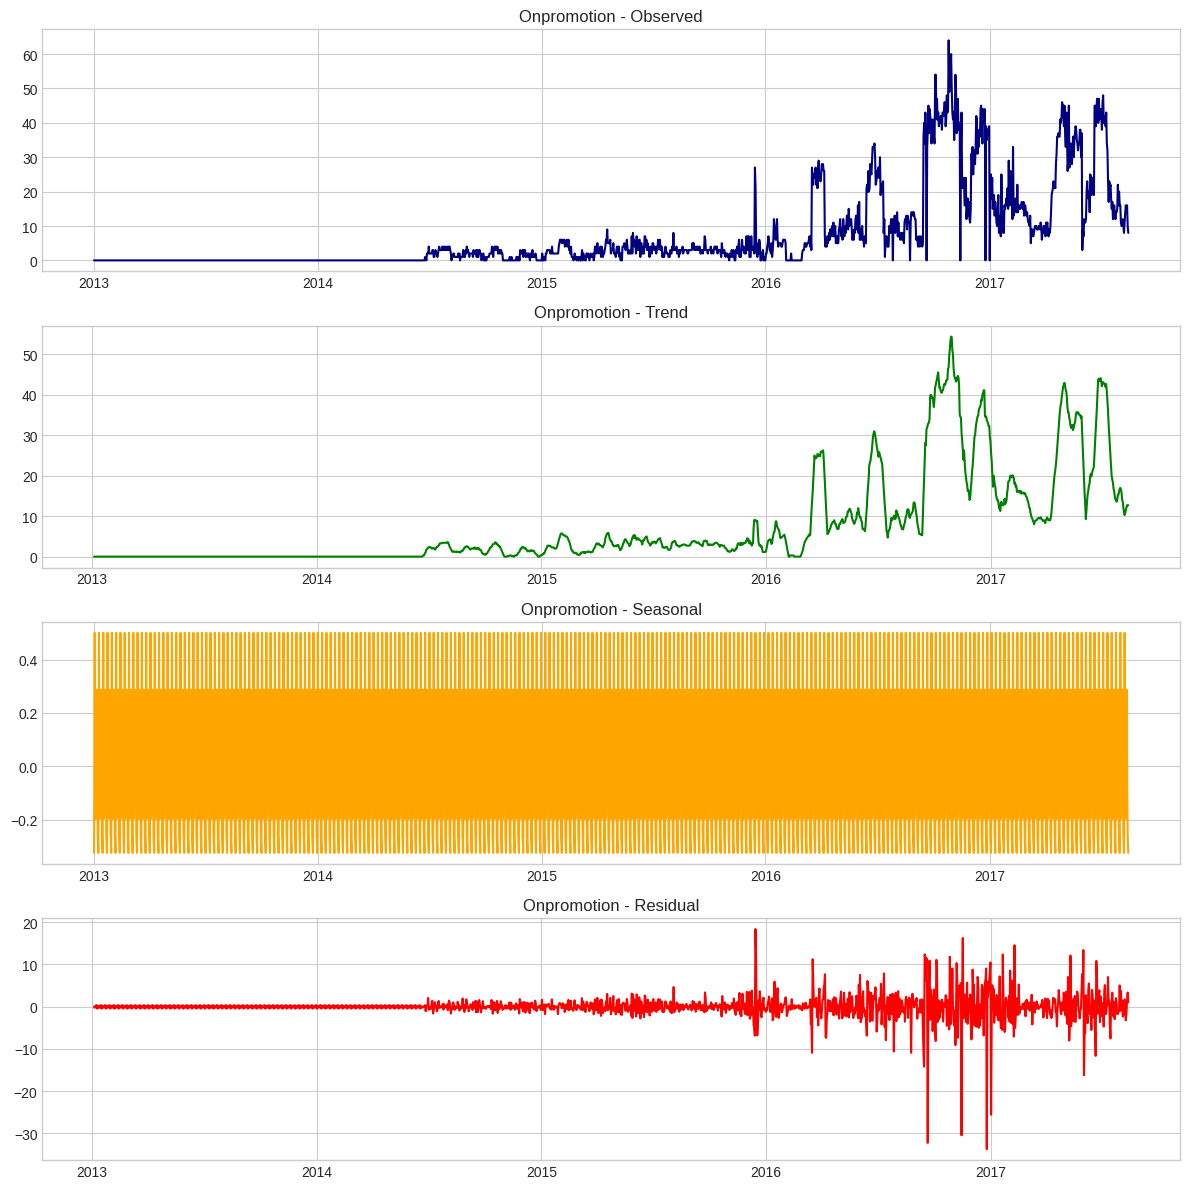

In [36]:
# Decomposition untuk Onpromotion
decomp_onpromo = seasonal_decompose(df_cleaning_indexed['onpromotion'], model='additive', period=7)

plt.figure(figsize=(12, 12))
plt.subplot(4, 1, 1)
plt.plot(decomp_onpromo.observed, color='navy')
plt.title("Onpromotion - Observed")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(decomp_onpromo.trend, color='green')
plt.title("Onpromotion - Trend")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(decomp_onpromo.seasonal, color='orange')
plt.title("Onpromotion - Seasonal")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(decomp_onpromo.resid, color='red')
plt.title("Onpromotion - Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

PREAPARING THE DATA

In [38]:

# Pastikan data lengkap untuk semua tanggal
df_complete = df_store[df_store['family'] == 'CLEANING'].copy()

# Set date sebagai index dan reindex untuk memastikan semua tanggal ada
full_date_range = pd.date_range(start=df_complete['date'].min(), end=df_complete['date'].max(), freq='D')
df_complete = df_complete.set_index('date').reindex(full_date_range).reset_index()

# Rename kolom index menjadi date
df_complete = df_complete.rename(columns={'index': 'date'})

# Isi nilai yang hilang
df_complete.loc[:, 'sales'] = df_complete['sales'].fillna(0)
df_complete.loc[:, 'onpromotion'] = df_complete['onpromotion'].fillna(0)
df_complete.loc[:, 'store_nbr'] = df_complete['store_nbr'].fillna(5).astype(int)
df_complete.loc[:, 'family'] = df_complete['family'].fillna('CLEANING')

# Transformasi Box-Cox untuk onpromotion
df_complete.loc[:, 'onpromotion_boxcox'], lambda_bc = boxcox(df_complete['onpromotion'] + 1)
print(f"Transformasi Box-Cox diterapkan dengan lambda = {lambda_bc:.4f}")


Transformasi Box-Cox diterapkan dengan lambda = -0.2770


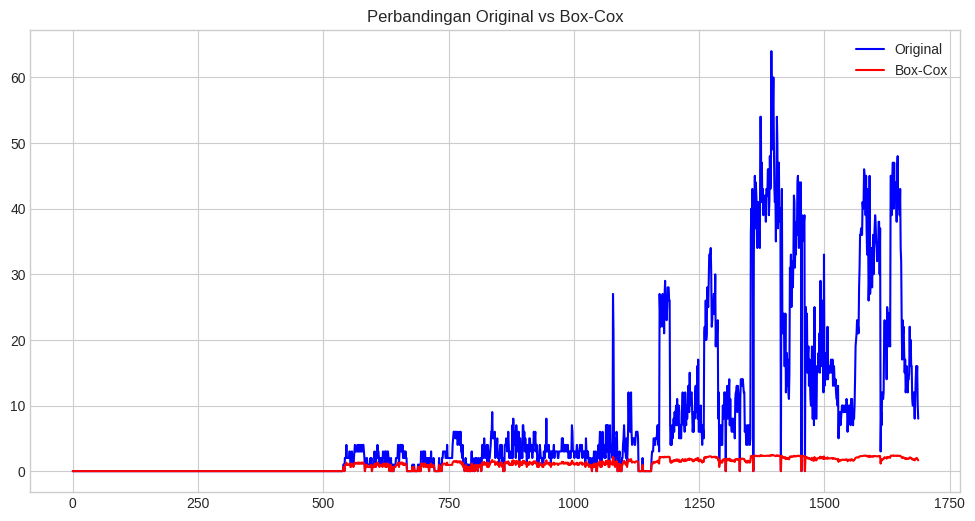

In [39]:
# Visualisasi hasil transformasi
plt.figure(figsize=(12, 6))
plt.plot(df_complete.index, df_complete['onpromotion'], label='Original', color='blue')
plt.plot(df_complete.index, df_complete['onpromotion_boxcox'], label='Box-Cox', color='red')
plt.title('Perbandingan Original vs Box-Cox')
plt.legend()
plt.show()

# Interpolasi dcoilwtico
df_complete.loc[:, 'dcoilwtico_interpolate'] = (
    df_complete['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .bfill()
)

In [40]:
# Set index tanggal untuk model time series
df_complete = df_complete.set_index('date')

# Cek missing values setelah preprocessing
print("\nMissing Values Setelah Preprocessing Lengkap:")
print(df_complete.isnull().sum())



Missing Values Setelah Preprocessing Lengkap:
id                          4
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
dcoilwtico                525
dcoilwtico_interpolate      0
onpromotion_boxcox          0
dtype: int64


SPLIT DATA TEST & TRAINING

In [41]:
endog = df_complete[['sales', 'onpromotion_boxcox']]
exog = df_complete[['dcoilwtico_interpolate']]

# 80% data untuk training, 20% untuk testing
train_size = int(len(df_cleaning_indexed) * 0.8)
train_endog = endog.iloc[:train_size]
test_endog = endog.iloc[train_size:]
train_exog = exog.iloc[:train_size]
test_exog = exog.iloc[train_size:]

print(f"Ukuran data training: {train_endog.shape}")
print(f"Ukuran data testing: {test_endog.shape}")


Ukuran data training: (1350, 2)
Ukuran data testing: (338, 2)


VARMAX

In [43]:
# Grid search untuk parameter p dan q
p_values = range(1, 4)  # Order autoregressive
q_values = range(0, 3)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

# Hitung rata-rata aktual untuk normalisasi
mean_sales = test_endog['sales'].mean()
mean_promo = test_endog['onpromotion_boxcox'].mean()

# Coba semua kombinasi (p, q)
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model.fit(disp=False)

        # Forecast untuk data test
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1
        test_endog_copy = test_endog.copy()
        test_endog_copy.loc[:, 'onpromotion'] = inv_boxcox(test_endog_copy['onpromotion_boxcox'], lambda_bc) - 1

        # Hitung MAE antara prediksi dan data aktual
        mae_sales = mean_absolute_error(test_endog_copy['sales'], preds['sales'])
        mae_promo = mean_absolute_error(test_endog_copy['onpromotion'], preds['onpromotion'])

        # Normalisasi MAE
        mae_sales_norm = mae_sales / mean_sales if mean_sales > 0 else mae_sales
        mae_promo_norm = mae_promo / mean_promo if mean_promo > 0 else mae_promo
        mae_normalized = mae_sales_norm + mae_promo_norm

        print(f"VARMAX({p},{q}) - Normalized MAE: {mae_normalized:.4f}")

        # Simpan model dengan MAE terbaik
        if mae_normalized < best_score:
            best_score = mae_normalized
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized MAE: {best_score:.4f}")


Evaluating VARMAX(1,0)...
VARMAX(1,0) - Normalized MAE: 11.4268
Evaluating VARMAX(1,1)...
VARMAX(1,1) - Normalized MAE: 11.3355
Evaluating VARMAX(1,2)...
VARMAX(1,2) - Normalized MAE: 11.4010
Evaluating VARMAX(2,0)...
VARMAX(2,0) - Normalized MAE: 11.3521
Evaluating VARMAX(2,1)...
VARMAX(2,1) - Normalized MAE: 11.3531
Evaluating VARMAX(2,2)...
VARMAX(2,2) - Normalized MAE: 11.4385
Evaluating VARMAX(3,0)...
VARMAX(3,0) - Normalized MAE: 11.3270
Evaluating VARMAX(3,1)...
VARMAX(3,1) - Normalized MAE: 11.2554
Evaluating VARMAX(3,2)...
VARMAX(3,2) - Normalized MAE: 11.3872

Best VARMAX order: (3, 1) dengan Normalized MAE: 11.2554


EVALUATE THE MODEL

In [44]:
# Generate predictions dari model terbaik
varmax_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal
varmax_preds['onpromotion'] = inv_boxcox(varmax_preds['onpromotion_boxcox'], lambda_bc) - 1
test_endog_copy = test_endog.copy()
test_endog_copy.loc[:, 'onpromotion'] = inv_boxcox(test_endog_copy['onpromotion_boxcox'], lambda_bc) - 1

# Hitung RMSE
rmse_sales = np.sqrt(mean_squared_error(test_endog_copy['sales'], varmax_preds['sales']))
rmse_onpromotion = np.sqrt(mean_squared_error(test_endog_copy['onpromotion'], varmax_preds['onpromotion']))

print(f'RMSE for Sales (VARMAX): {rmse_sales:.4f}')
print(f'RMSE for Onpromotion (VARMAX): {rmse_onpromotion:.4f}')

RMSE for Sales (VARMAX): 226.2571
RMSE for Onpromotion (VARMAX): 26.5769


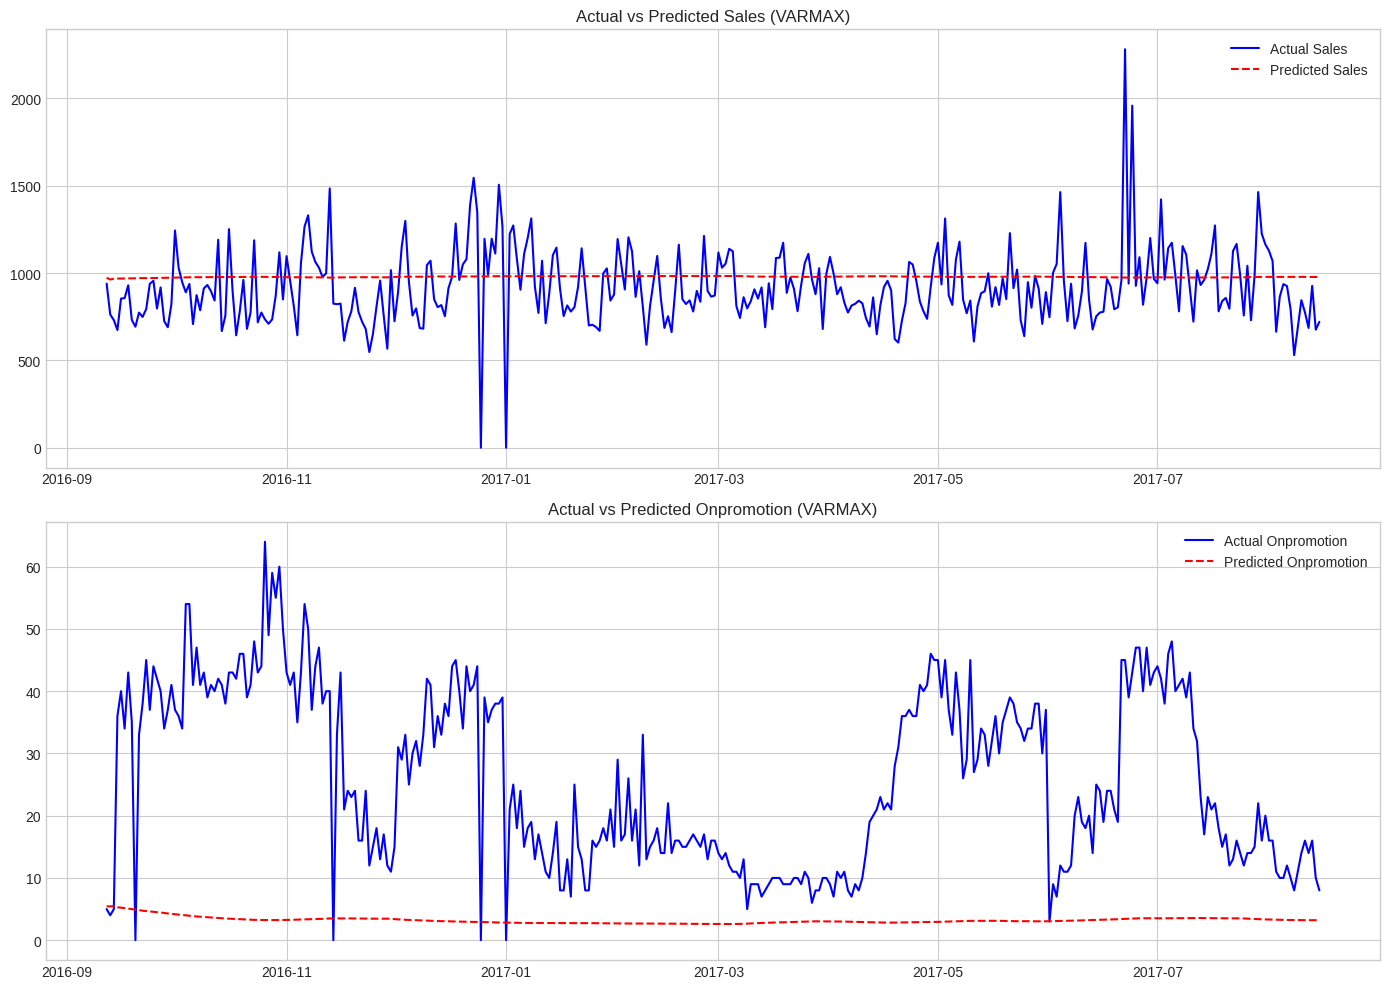

In [45]:
plt.figure(figsize=(14, 10))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog_copy['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, varmax_preds['sales'], label='Predicted Sales', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales (VARMAX)')
plt.legend()
plt.grid(True)

# Plot Onpromotion
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog_copy['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, varmax_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='--')
plt.title('Actual vs Predicted Onpromotion (VARMAX)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

PREPARING THE DATA FOR LSTM MODEL

In [47]:
# Normalisasi data
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

endog_scaled = scaler_endog.fit_transform(df_complete[['sales', 'onpromotion']])
exog_scaled = scaler_exog.fit_transform(df_complete[['dcoilwtico_interpolate']])

# Gabungkan fitur
features = np.concatenate([exog_scaled, endog_scaled], axis=1)
target = endog_scaled  # Target adalah kolom sales dan onpromotion yang sudah dinormalisasi

print(f"Shape features: {features.shape}")
print(f"Shape target: {target.shape}")

# Fungsi untuk load data LSTM
def load_data_lstm(X, seq_len, train_size=0.9):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape: {y_train.shape}")

    # Make sure y_train and y_test have 2 columns (for 'sales' and 'onpromotion')
    assert y_train.shape[1] == 2, "y_train should have 2 columns (sales and onpromotion)"
    assert y_test.shape[1] == 2, "y_test should have 2 columns (sales and onpromotion)"

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting ukuran window
window = 22  # ~ 3 minggu + 1 hari
X_train, y_train, X_test, y_test = load_data_lstm(features, window, train_size=0.8)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Dictionary untuk menyimpan hasil model
models_results = {}

Shape features: (1688, 3)
Shape target: (1688, 2)
x_train shape (before reshape): (1332, 22, 3)
y_train shape: (1332, 2)
X_train shape: (1332, 22, 3), y_train shape: (1332, 2)
X_test shape: (333, 22, 3), y_test shape: (333, 2)


In [48]:
model_single = Sequential()
model_single.add(LSTM(units=50, input_shape=(window, X_train.shape[2])))
model_single.add(Dropout(0.2))
model_single.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model_single.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs
model_single.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
start_time = time.time()
history_single = model_single.fit(
    X_train, y_train,
    epochs=100,
    batch_size=35,
    validation_split=0.05,
    verbose=1
)
train_time_single = time.time() - start_time
print(f'Training time: {train_time_single:.2f} seconds')

# Evaluasi model
train_predict_single = model_single.predict(X_train)
test_predict_single = model_single.predict(X_test)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0607 - val_loss: 0.0121
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - val_loss: 0.0113
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0086 - val_loss: 0.0079
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0074 - val_loss: 0.0080
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0076
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0067 - val_loss: 0.0082
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0064 - val_loss: 0.0086
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0063 - val_loss: 0.0087
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - val_loss: 0.0074
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0063 - val_loss: 0.0080
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0062 - val_loss: 0.0068
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

In [49]:

# Inverse transform
train_predict_inv_single = scaler_endog.inverse_transform(train_predict_single)
train_y_inv_single = scaler_endog.inverse_transform(y_train)
test_predict_inv_single = scaler_endog.inverse_transform(test_predict_single)
test_y_inv_single = scaler_endog.inverse_transform(y_test)

# Hitung RMSE
train_rmse_sales_single = np.sqrt(mean_squared_error(train_y_inv_single[:, 0], train_predict_inv_single[:, 0]))
test_rmse_sales_single = np.sqrt(mean_squared_error(test_y_inv_single[:, 0], test_predict_inv_single[:, 0]))
train_rmse_onpromo_single = np.sqrt(mean_squared_error(train_y_inv_single[:, 1], train_predict_inv_single[:, 1]))
test_rmse_onpromo_single = np.sqrt(mean_squared_error(test_y_inv_single[:, 1], test_predict_inv_single[:, 1]))

print(f'Train Score for sales: {train_rmse_sales_single:.2f} RMSE')
print(f'Test Score for sales: {test_rmse_sales_single:.2f} RMSE')
print(f'Train Score for onpromotion: {train_rmse_onpromo_single:.2f} RMSE')
print(f'Test Score for onpromotion: {test_rmse_onpromo_single:.2f} RMSE')

# Simpan hasil untuk perbandingan
models_results['Single LSTM'] = {
    'train_rmse_sales': train_rmse_sales_single,
    'test_rmse_sales': test_rmse_sales_single,
    'train_rmse_onpromo': train_rmse_onpromo_single,
    'test_rmse_onpromo': test_rmse_onpromo_single
}

Train Score for sales: 201.30 RMSE
Test Score for sales: 230.57 RMSE
Train Score for onpromotion: 2.22 RMSE
Test Score for onpromotion: 7.80 RMSE


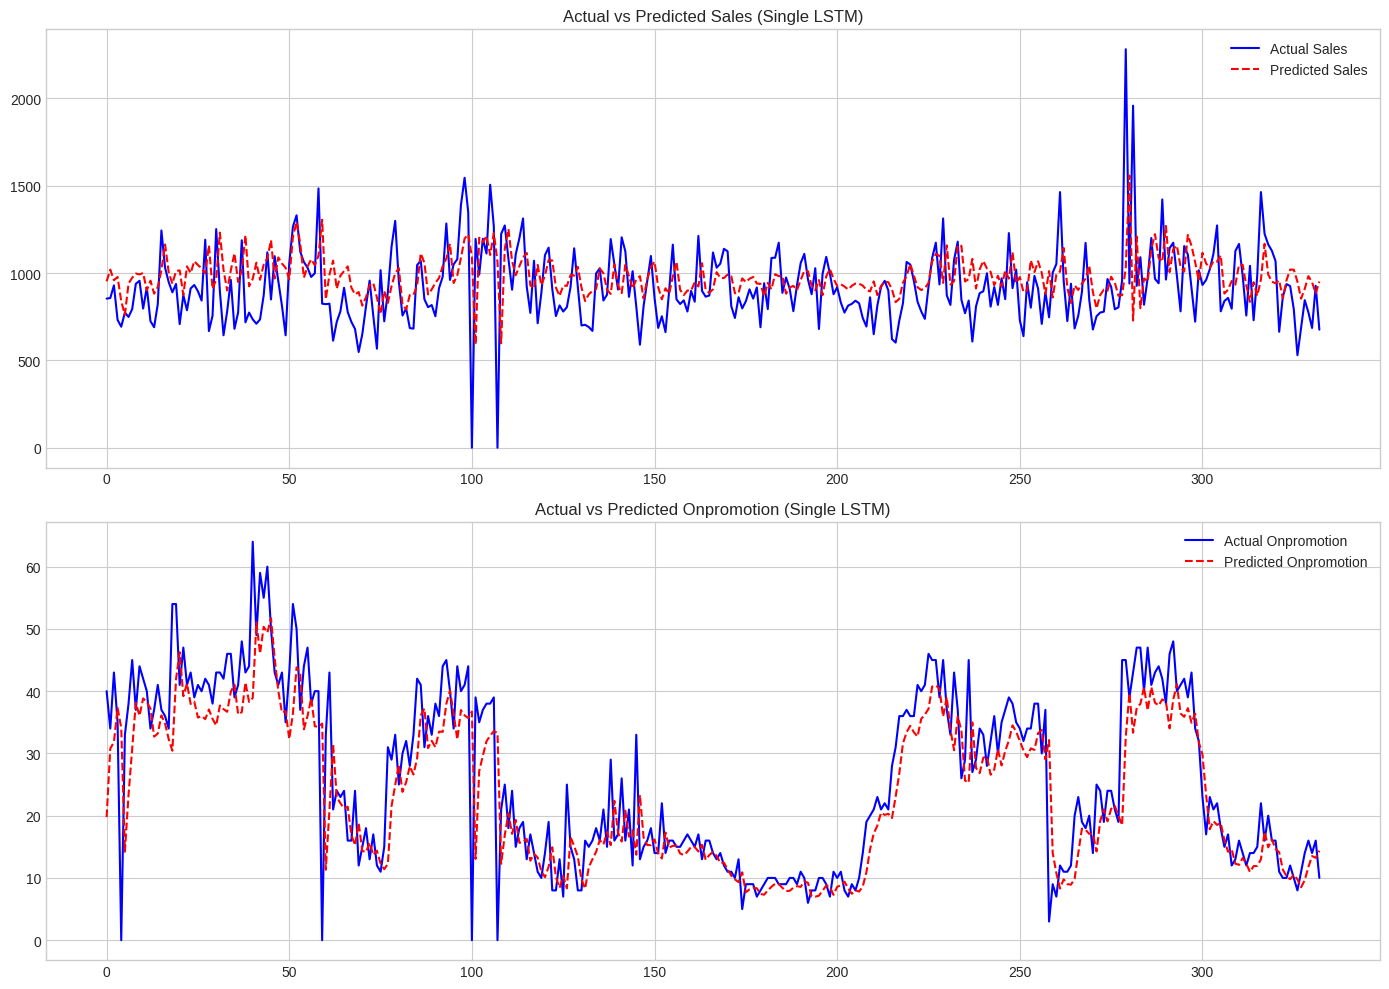

In [51]:
plt.figure(figsize=(14, 10))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_y_inv_single[:, 0], label='Actual Sales', color='blue')
plt.plot(test_predict_inv_single[:, 0], label='Predicted Sales', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales (Single LSTM)')
plt.legend()
plt.grid(True)

# Plot Onpromotion
plt.subplot(2, 1, 2)
plt.plot(test_y_inv_single[:, 1], label='Actual Onpromotion', color='blue')
plt.plot(test_predict_inv_single[:, 1], label='Predicted Onpromotion', color='red', linestyle='--')
plt.title('Actual vs Predicted Onpromotion (Single LSTM)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

STACK LSTM

In [52]:
model_stacked = Sequential()

# First LSTM layer
model_stacked.add(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2])))
model_stacked.add(Dropout(0.2))

# Second LSTM layer
model_stacked.add(LSTM(units=50, return_sequences=True))
model_stacked.add(Dropout(0.2))

# Third LSTM layer
model_stacked.add(LSTM(units=50))
model_stacked.add(Dropout(0.2))

# Dense layers
model_stacked.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model_stacked.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs

# Compile model
model_stacked.compile(optimizer='adam', loss='mean_squared_error')

# Latih model
start_time = time.time()
history_stacked = model_stacked.fit(
    X_train, y_train,
    epochs=100,
    batch_size=35,
    validation_split=0.05,
    verbose=1
)
train_time_stacked = time.time() - start_time
print(f'Training time: {train_time_stacked:.2f} seconds')

# Evaluasi model
train_predict_stacked = model_stacked.predict(X_train)
test_predict_stacked = model_stacked.predict(X_test)

# Inverse transform
train_predict_inv_stacked = scaler_endog.inverse_transform(train_predict_stacked)
train_y_inv_stacked = scaler_endog.inverse_transform(y_train)
test_predict_inv_stacked = scaler_endog.inverse_transform(test_predict_stacked)
test_y_inv_stacked = scaler_endog.inverse_transform(y_test)

# Hitung RMSE
train_rmse_sales_stacked = np.sqrt(mean_squared_error(train_y_inv_stacked[:, 0], train_predict_inv_stacked[:, 0]))
test_rmse_sales_stacked = np.sqrt(mean_squared_error(test_y_inv_stacked[:, 0], test_predict_inv_stacked[:, 0]))
train_rmse_onpromo_stacked = np.sqrt(mean_squared_error(train_y_inv_stacked[:, 1], train_predict_inv_stacked[:, 1]))
test_rmse_onpromo_stacked = np.sqrt(mean_squared_error(test_y_inv_stacked[:, 1], test_predict_inv_stacked[:, 1]))

print(f'Train Score for sales: {train_rmse_sales_stacked:.2f} RMSE')
print(f'Test Score for sales: {test_rmse_sales_stacked:.2f} RMSE')
print(f'Train Score for onpromotion: {train_rmse_onpromo_stacked:.2f} RMSE')
print(f'Test Score for onpromotion: {test_rmse_onpromo_stacked:.2f} RMSE')

# Simpan hasil untuk perbandingan
models_results['Stacked LSTM'] = {
    'train_rmse_sales': train_rmse_sales_stacked,
    'test_rmse_sales': test_rmse_sales_stacked,
    'train_rmse_onpromo': train_rmse_onpromo_stacked,
    'test_rmse_onpromo': test_rmse_onpromo_stacked
}

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 0.0590 - val_loss: 0.0126
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0100 - val_loss: 0.0125
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0092 - val_loss: 0.0120
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0091 - val_loss: 0.0100
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0096 - val_loss: 0.0072
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0080 - val_loss: 0.0072
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0078 - val_loss: 0.0078
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0070 - val_loss: 0.0090
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0072 - val_loss: 0.0089
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0068 - val_loss: 0.0094
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0068 - val_loss: 0.0082
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/ste

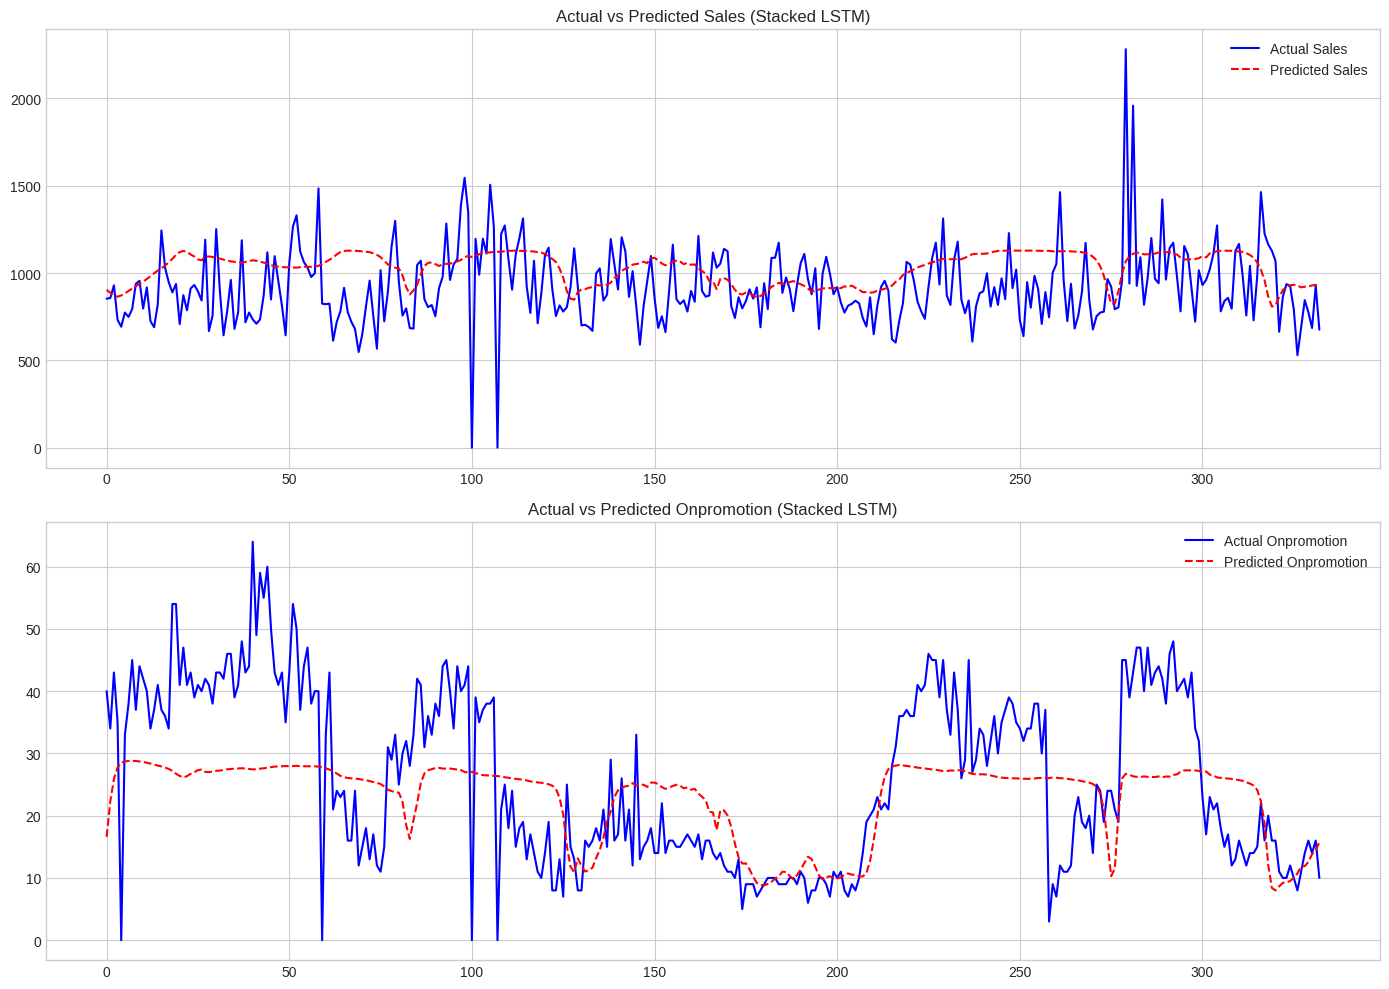

In [53]:
plt.figure(figsize=(14, 10))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_y_inv_stacked[:, 0], label='Actual Sales', color='blue')
plt.plot(test_predict_inv_stacked[:, 0], label='Predicted Sales', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales (Stacked LSTM)')
plt.legend()
plt.grid(True)

# Plot Onpromotion
plt.subplot(2, 1, 2)
plt.plot(test_y_inv_stacked[:, 1], label='Actual Onpromotion', color='blue')
plt.plot(test_predict_inv_stacked[:, 1], label='Predicted Onpromotion', color='red', linestyle='--')
plt.title('Actual vs Predicted Onpromotion (Stacked LSTM)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Bidirectional LSTM

In [54]:
# Buat scaler baru untuk y_train khusus model bidirectional
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = y_scaler.fit_transform(y_train)

model_bidirectional = Sequential()
model_bidirectional.add(Bidirectional(LSTM(units=50), input_shape=(window, X_train.shape[2])))
model_bidirectional.add(Dropout(0.2))
model_bidirectional.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model_bidirectional.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))

# Compile model
model_bidirectional.compile(optimizer='adam', loss='mean_squared_error')

# Tambahkan early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, verbose=1, mode='min')

# Latih model
start_time = time.time()
history_bidirectional = model_bidirectional.fit(
    X_train, y_train,
    epochs=100,
    batch_size=35,
    validation_split=0.05,
    verbose=1,
    callbacks=[early_stop]
)
train_time_bidirectional = time.time() - start_time
print(f'Training time: {train_time_bidirectional:.2f} seconds')

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0653 - val_loss: 0.0097
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0093 - val_loss: 0.0086
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0077 - val_loss: 0.0072
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0073 - val_loss: 0.0081
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - val_loss: 0.0139
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0061 - val_loss: 0.0080
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0059 - val_loss: 0.0095
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060 - val_loss: 0.0069
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - val_loss: 0.0076
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052 - val_loss: 0.0072
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0063 - val_loss: 0.0071
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

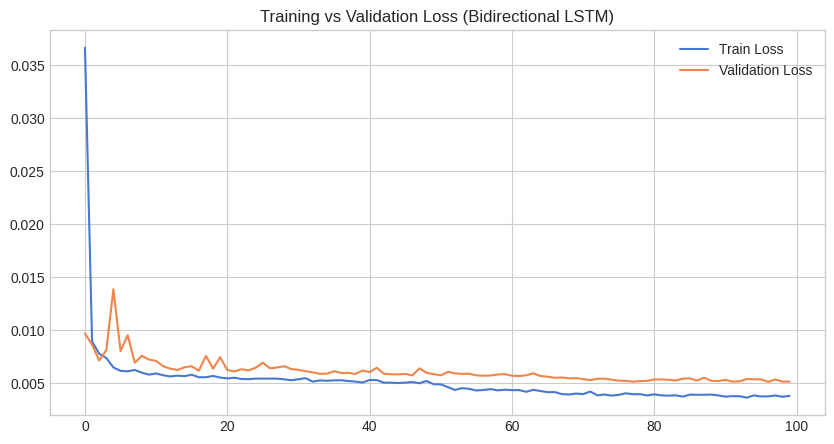

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(history_bidirectional.history['loss'], label='Train Loss')
plt.plot(history_bidirectional.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Bidirectional LSTM)')
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# Evaluasi model
train_predict_bidirectional = model_bidirectional.predict(X_train)
test_predict_bidirectional = model_bidirectional.predict(X_test)

# Inverse transform dengan scaler yang sama dengan data training
train_predict_inv_bidirectional = scaler_endog.inverse_transform(train_predict_bidirectional)
train_y_inv_bidirectional = scaler_endog.inverse_transform(y_train)
test_predict_inv_bidirectional = scaler_endog.inverse_transform(test_predict_bidirectional)
test_y_inv_bidirectional = scaler_endog.inverse_transform(y_test)

# Hitung RMSE
train_rmse_sales_bidirectional = np.sqrt(mean_squared_error(train_y_inv_bidirectional[:, 0], train_predict_inv_bidirectional[:, 0]))
test_rmse_sales_bidirectional = np.sqrt(mean_squared_error(test_y_inv_bidirectional[:, 0], test_predict_inv_bidirectional[:, 0]))
train_rmse_onpromo_bidirectional = np.sqrt(mean_squared_error(train_y_inv_bidirectional[:, 1], train_predict_inv_bidirectional[:, 1]))
test_rmse_onpromo_bidirectional = np.sqrt(mean_squared_error(test_y_inv_bidirectional[:, 1], test_predict_inv_bidirectional[:, 1]))

print(f'Train Score for sales: {train_rmse_sales_bidirectional:.2f} RMSE')
print(f'Test Score for sales: {test_rmse_sales_bidirectional:.2f} RMSE')
print(f'Train Score for onpromotion: {train_rmse_onpromo_bidirectional:.2f} RMSE')
print(f'Test Score for onpromotion: {test_rmse_onpromo_bidirectional:.2f} RMSE')

# Simpan hasil untuk perbandingan
models_results['Bidirectional LSTM'] = {
    'train_rmse_sales': train_rmse_sales_bidirectional,
    'test_rmse_sales': test_rmse_sales_bidirectional,
    'train_rmse_onpromo': train_rmse_onpromo_bidirectional,
    'test_rmse_onpromo': test_rmse_onpromo_bidirectional
}

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Train Score for sales: 177.83 RMSE
Test Score for sales: 218.55 RMSE
Train Score for onpromotion: 2.17 RMSE
Test Score for onpromotion: 7.79 RMSE


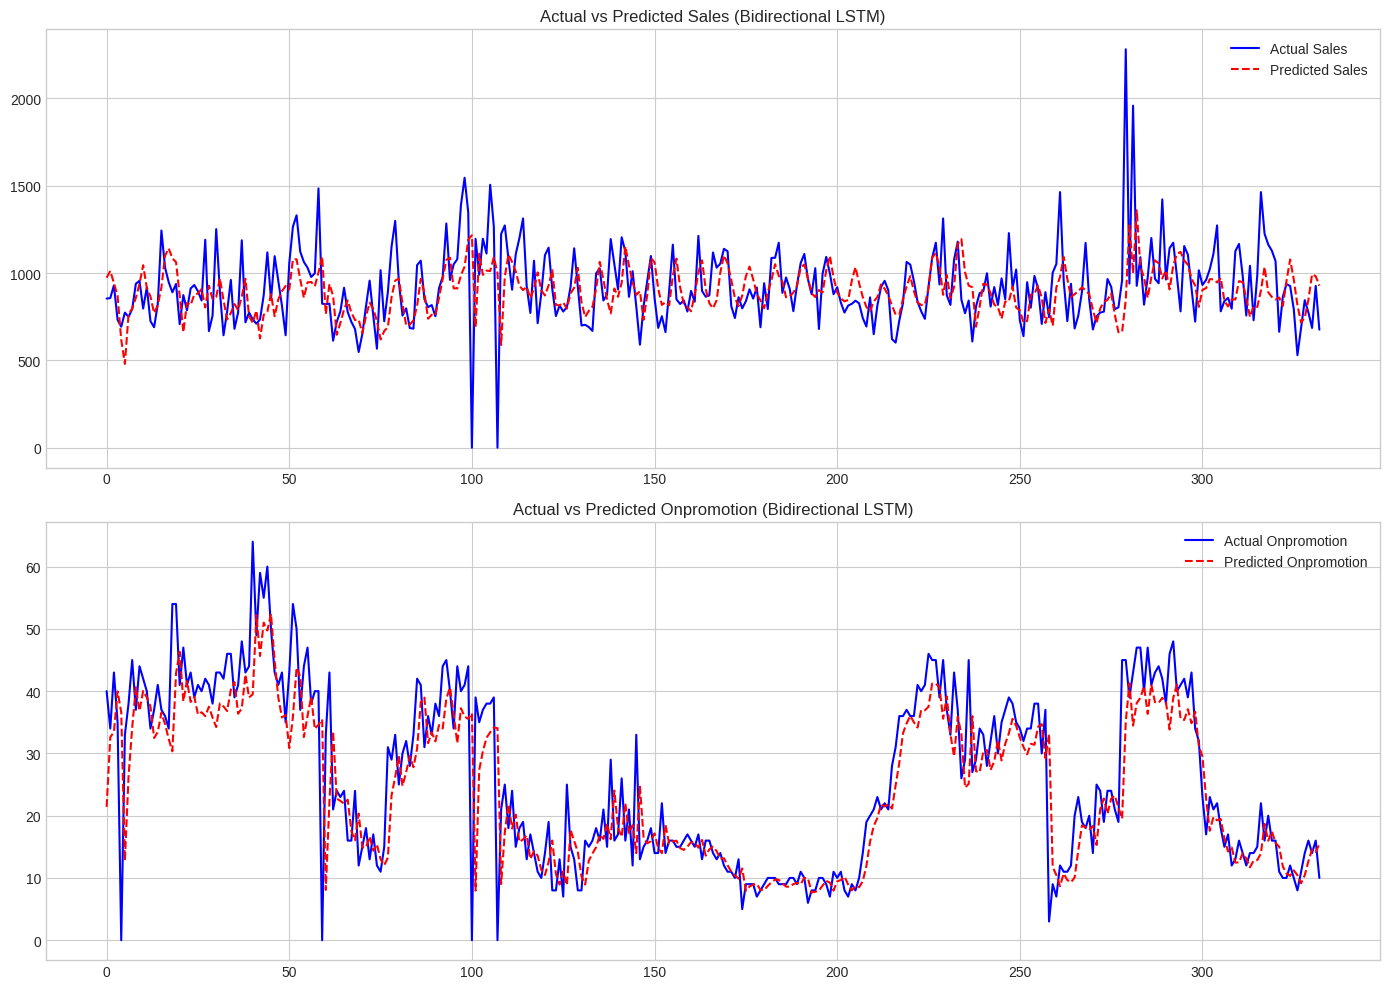

In [57]:

# Visualisasi hasil Bidirectional LSTM
plt.figure(figsize=(14, 10))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_y_inv_bidirectional[:, 0], label='Actual Sales', color='blue')
plt.plot(test_predict_inv_bidirectional[:, 0], label='Predicted Sales', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales (Bidirectional LSTM)')
plt.legend()
plt.grid(True)

# Plot Onpromotion
plt.subplot(2, 1, 2)
plt.plot(test_y_inv_bidirectional[:, 1], label='Actual Onpromotion', color='blue')
plt.plot(test_predict_inv_bidirectional[:, 1], label='Predicted Onpromotion', color='red', linestyle='--')
plt.title('Actual vs Predicted Onpromotion (Bidirectional LSTM)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [58]:

# Tambahkan hasil VARMAX ke perbandingan
models_results['VARMAX'] = {
    'train_rmse_sales': None,  # Tidak ada RMSE training untuk VARMAX
    'test_rmse_sales': rmse_sales,
    'train_rmse_onpromo': None,
    'test_rmse_onpromo': rmse_onpromotion
}

PERBANDINGAN ANTAR MODEL

                 Model              Metrik       Nilai
0          Single LSTM    train_rmse_sales  201.300229
1          Single LSTM     test_rmse_sales  230.569856
2          Single LSTM  train_rmse_onpromo    2.223081
3          Single LSTM   test_rmse_onpromo    7.801937
4         Stacked LSTM    train_rmse_sales  217.966825
5         Stacked LSTM     test_rmse_sales  249.490113
6         Stacked LSTM  train_rmse_onpromo    2.771446
7         Stacked LSTM   test_rmse_onpromo   11.716662
8   Bidirectional LSTM    train_rmse_sales  177.831413
9   Bidirectional LSTM     test_rmse_sales  218.546986
10  Bidirectional LSTM  train_rmse_onpromo    2.170839
11  Bidirectional LSTM   test_rmse_onpromo    7.785166
12              VARMAX     test_rmse_sales  226.257128
13              VARMAX   test_rmse_onpromo   26.576871

Perbandingan Model (Pivot):
Metrik              test_rmse_onpromo  test_rmse_sales  train_rmse_onpromo  \
Model                                                               

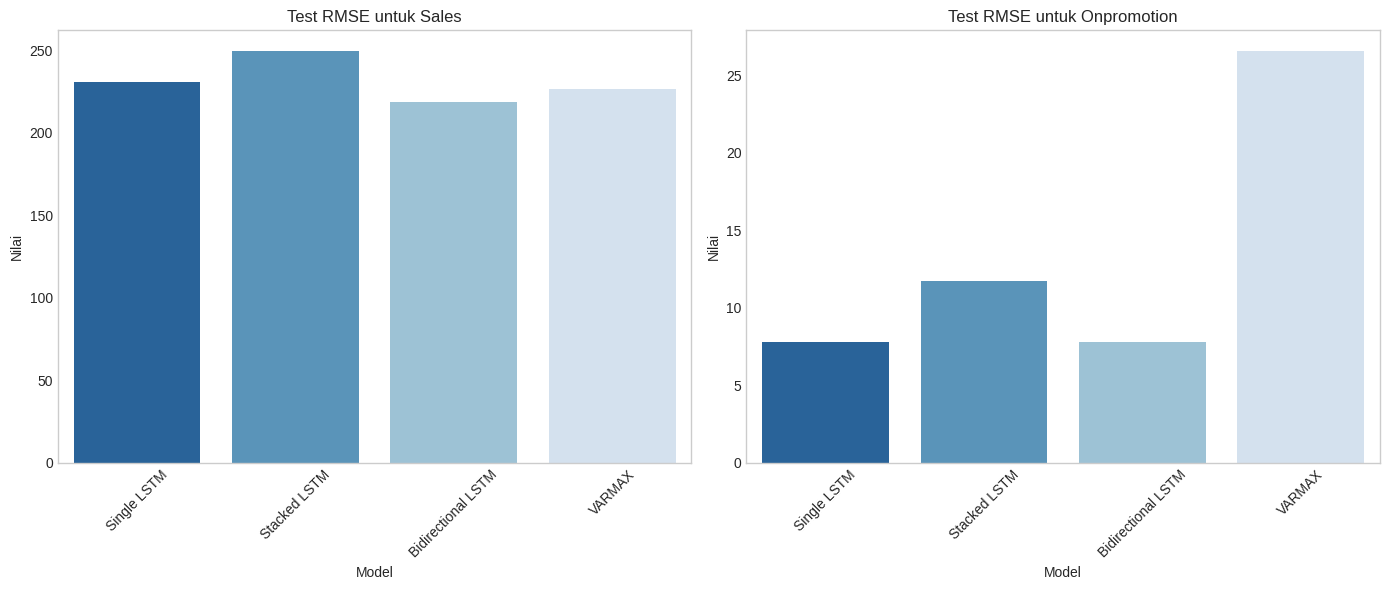

In [59]:
comparison_data = {
    'Model': [],
    'Metrik': [],
    'Nilai': []
}

for model_name, metrics in models_results.items():
    for metric_name, value in metrics.items():
        if value is not None:  # Skip None values
            comparison_data['Model'].append(model_name)
            comparison_data['Metrik'].append(metric_name)
            comparison_data['Nilai'].append(value)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Pivot untuk format yang lebih mudah dibaca
pivot_df = comparison_df.pivot(index='Model', columns='Metrik', values='Nilai')
print("\nPerbandingan Model (Pivot):")
print(pivot_df)

# Visualisasi perbandingan model
plt.figure(figsize=(14, 6))

# Plot RMSE Sales
plt.subplot(1, 2, 1)
test_sales_data = comparison_df[comparison_df['Metrik'] == 'test_rmse_sales']
sns.barplot(x='Model', y='Nilai', data=test_sales_data, palette='Blues_r')
plt.title('Test RMSE untuk Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Plot RMSE Onpromotion
plt.subplot(1, 2, 2)
test_onpromo_data = comparison_df[comparison_df['Metrik'] == 'test_rmse_onpromo']
sns.barplot(x='Model', y='Nilai', data=test_onpromo_data, palette='Blues_r')
plt.title('Test RMSE untuk Onpromotion')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [60]:
best_sales_model = pivot_df['test_rmse_sales'].idxmin()
best_onpromo_model = pivot_df['test_rmse_onpromo'].idxmin()

print(f"Model terbaik untuk prediksi Sales: {best_sales_model} dengan RMSE {pivot_df.loc[best_sales_model, 'test_rmse_sales']:.2f}")
print(f"Model terbaik untuk prediksi Onpromotion: {best_onpromo_model} dengan RMSE {pivot_df.loc[best_onpromo_model, 'test_rmse_onpromo']:.2f}")

Model terbaik untuk prediksi Sales: Bidirectional LSTM dengan RMSE 218.55
Model terbaik untuk prediksi Onpromotion: Bidirectional LSTM dengan RMSE 7.79
